# Práctica 3: análisis exploratorio de ENDIREH 2021

Este notebook utiliza **Polars** para analizar el conjunto previamente limpiado. El análisis es descriptivo: las asociaciones observadas no demuestran causalidad y deben comunicarse sin estigmatizar personas, grupos o entidades.

In [1]:
from pathlib import Path
import sys

PROYECTO = Path.cwd().resolve()
if PROYECTO.name == 'notebooks':
    PROYECTO = PROYECTO.parent
if str(PROYECTO) not in sys.path:
    sys.path.insert(0, str(PROYECTO))

import polars as pl
from IPython.display import Image, display
from config.rutas import ARCHIVO_ENDIREH_PROCESADO, RUTA_FIGURAS
from src.visualization.eda import main as generar_figuras

pl.Config.set_tbl_rows(40)
df = pl.read_parquet(ARCHIVO_ENDIREH_PROCESADO)
print(f'Polars {pl.__version__}')
print(f'Dimensiones: {df.shape}')

Polars 1.44.2
Dimensiones: (105715, 31)


## Clasificación de las variables principales

| Variable | Tipo de dato | Justificación |
|---|---|---|
| `edad_primer_union` | Cuantitativa discreta | Edad registrada en años cumplidos; admite operaciones aritméticas. |
| `num_hijos` | Cuantitativa discreta | Es un conteo de hijas e hijos. |
| `nom_entidad` | Cualitativa nominal | Identifica una entidad sin orden inherente. |
| `nivel_escolaridad` | Cualitativa ordinal | Sus niveles representan categorías ordenables; los códigos no son magnitudes. |
| `estado_civil_desc` | Cualitativa nominal | Sus categorías describen estados sin escala numérica. |
| `sufrio_violencia_pareja` | Cualitativa nominal dicotómica | Representa dos categorías: no reportó / sí reportó. |
| `factor_expansion` | Cuantitativa continua (ponderador) | Expresa cuántas mujeres de la población representa cada registro y se utiliza como peso. |

In [2]:
resumen_calidad = pl.DataFrame({
    'metrica': ['filas', 'columnas', 'duplicados', 'edad faltante', 'num_hijos faltante', 'ingreso faltante'],
    'valor': [df.height, df.width, int(df.is_duplicated().sum()), df['edad_primer_union'].null_count(), df['num_hijos'].null_count(), df['ingreso_pareja'].null_count()]
})
resumen_calidad

metrica,valor
str,i64
"""filas""",105715
"""columnas""",31
"""duplicados""",0
"""edad faltante""",95764
"""num_hijos faltante""",0
"""ingreso faltante""",0


La edad de primera unión conserva una proporción alta de datos faltantes. Se decidió no imputarla porque una sustitución masiva produciría una distribución artificial; sus gráficas y estadísticas utilizan exclusivamente casos válidos.

In [3]:
frecuencia_violencia = (
    df.group_by('sufrio_violencia_pareja')
      .agg(pl.len().alias('registros'), pl.col('factor_expansion').sum().alias('poblacion_representada'))
      .with_columns(
          (pl.col('registros') / pl.col('registros').sum() * 100).round(2).alias('porcentaje_muestral'),
          (pl.col('poblacion_representada') / pl.col('poblacion_representada').sum() * 100).round(2).alias('porcentaje_ponderado')
      )
      .sort('sufrio_violencia_pareja')
)
frecuencia_violencia

sufrio_violencia_pareja,registros,poblacion_representada,porcentaje_muestral,porcentaje_ponderado
u8,u32,u32,f64,f64
0,86516,40363293,81.84,82.15
1,19199,8769666,18.16,17.85


La diferencia entre el porcentaje muestral y el ponderado refleja el diseño de la encuesta. Para describir la población nacional debe privilegiarse el resultado ponderado.

Se generaron 6 figuras en: /Users/taniaramirez/Documents/Semestre Titulación/Almacenes/Practica3/proyecto-endireh-violencia/reports/figures


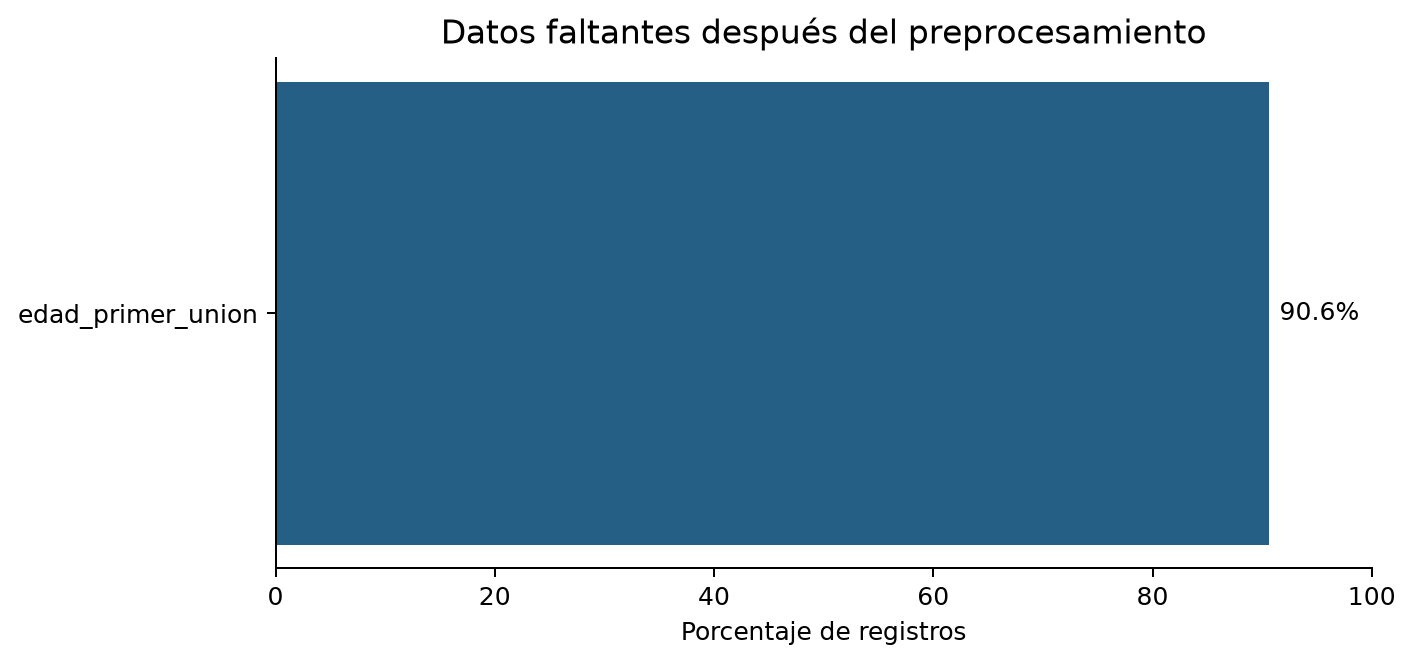

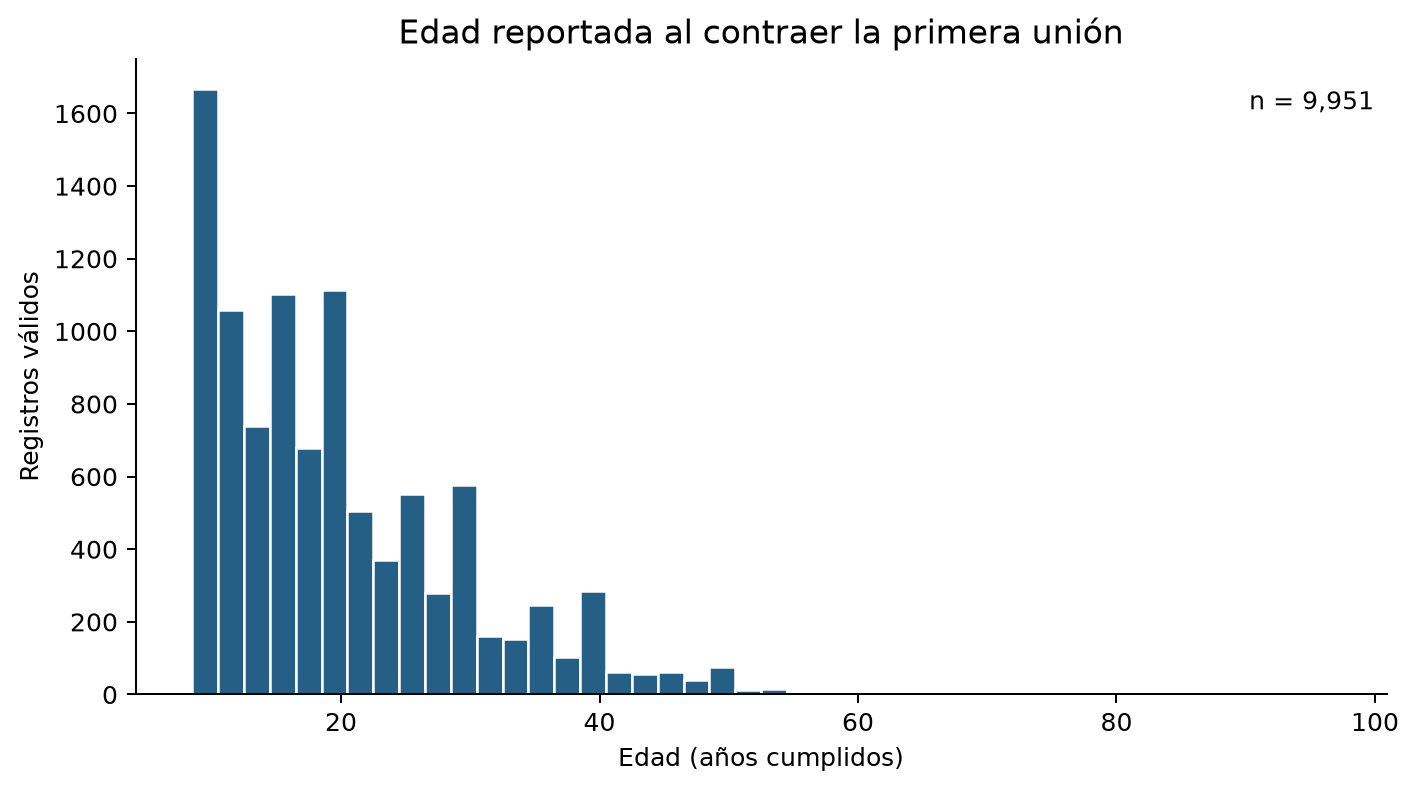

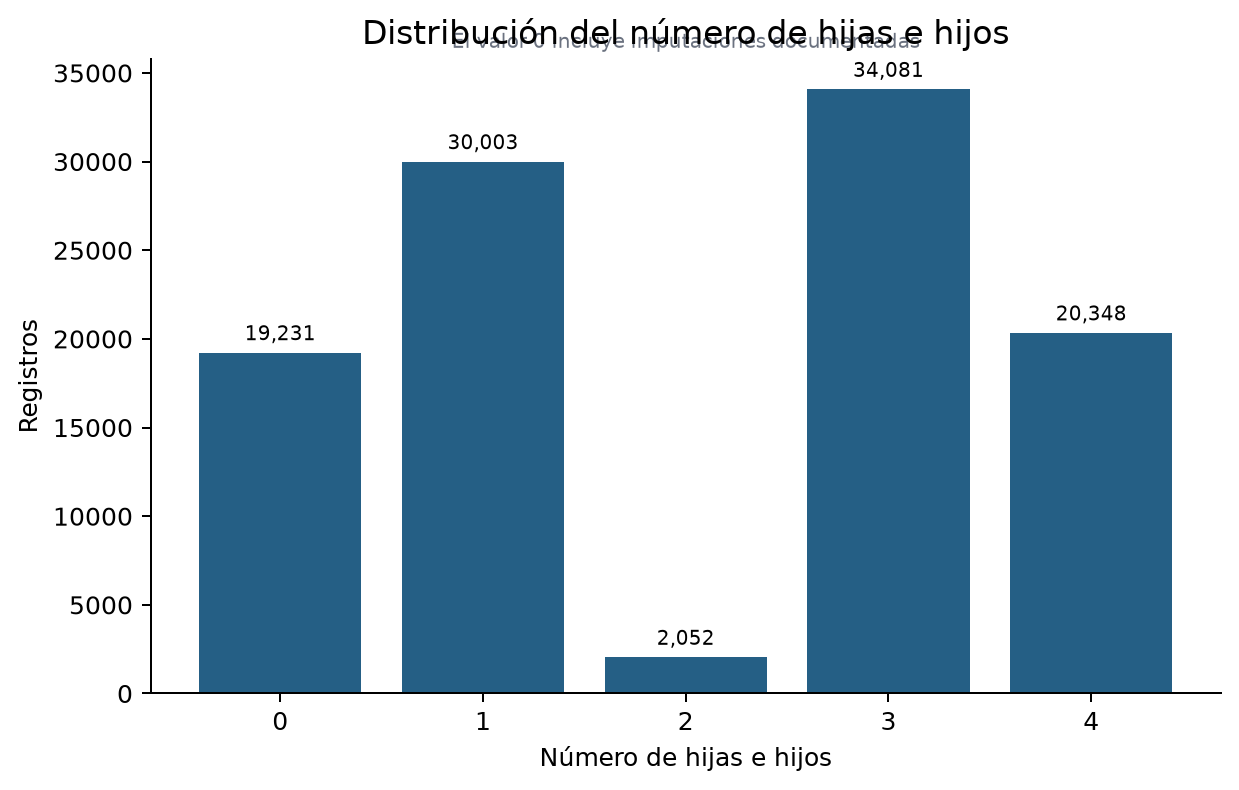

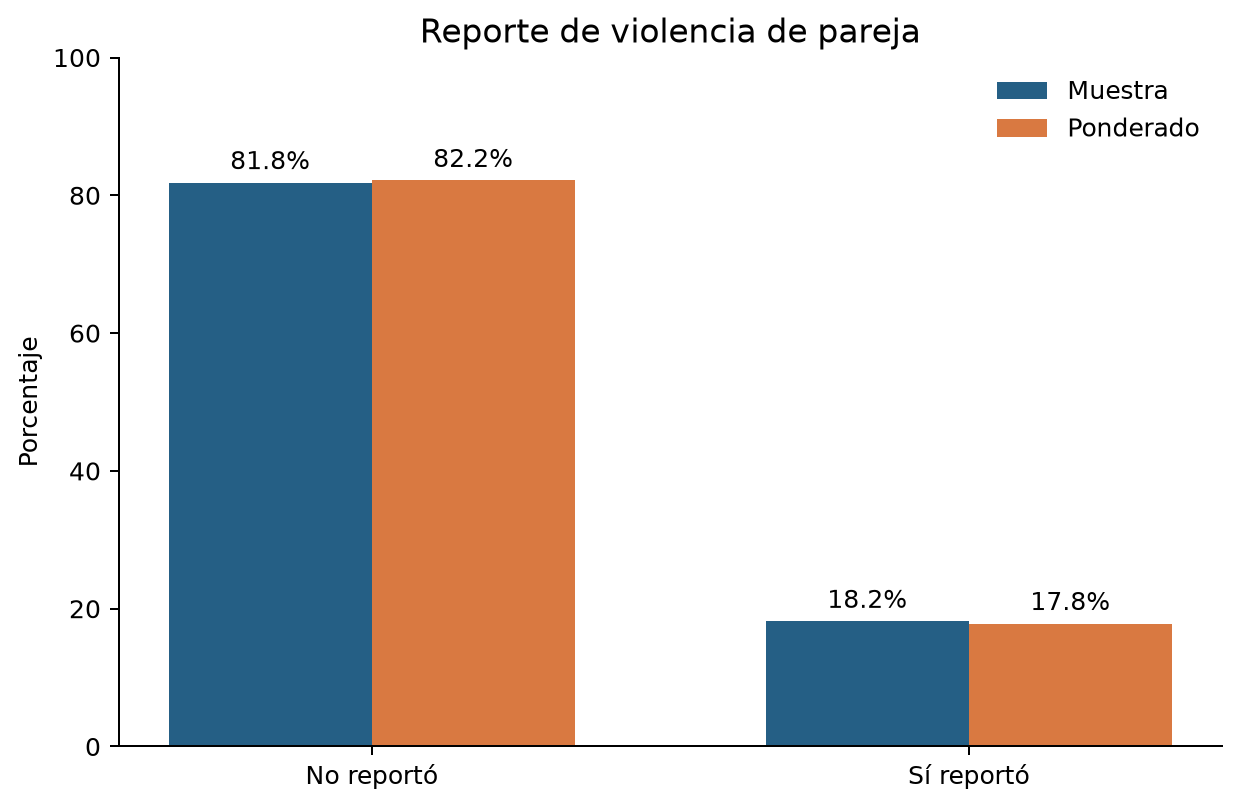

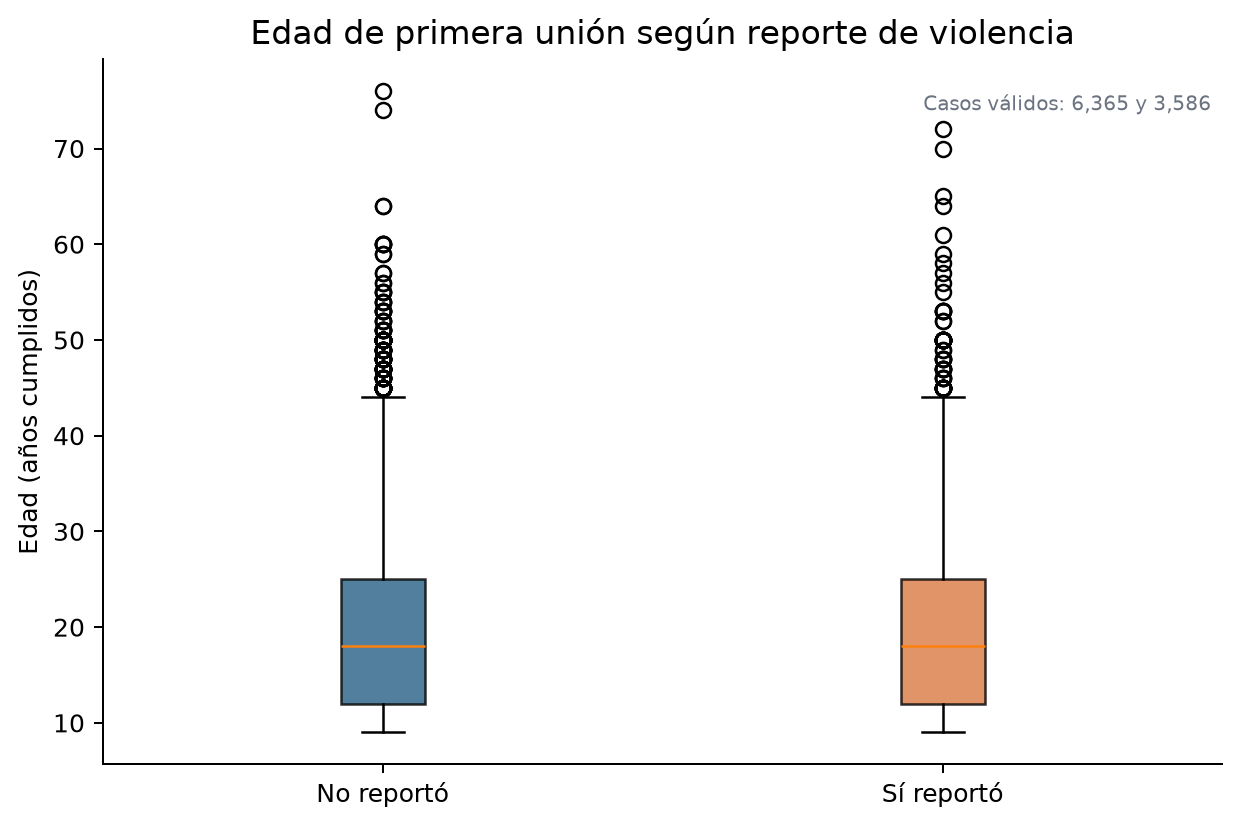

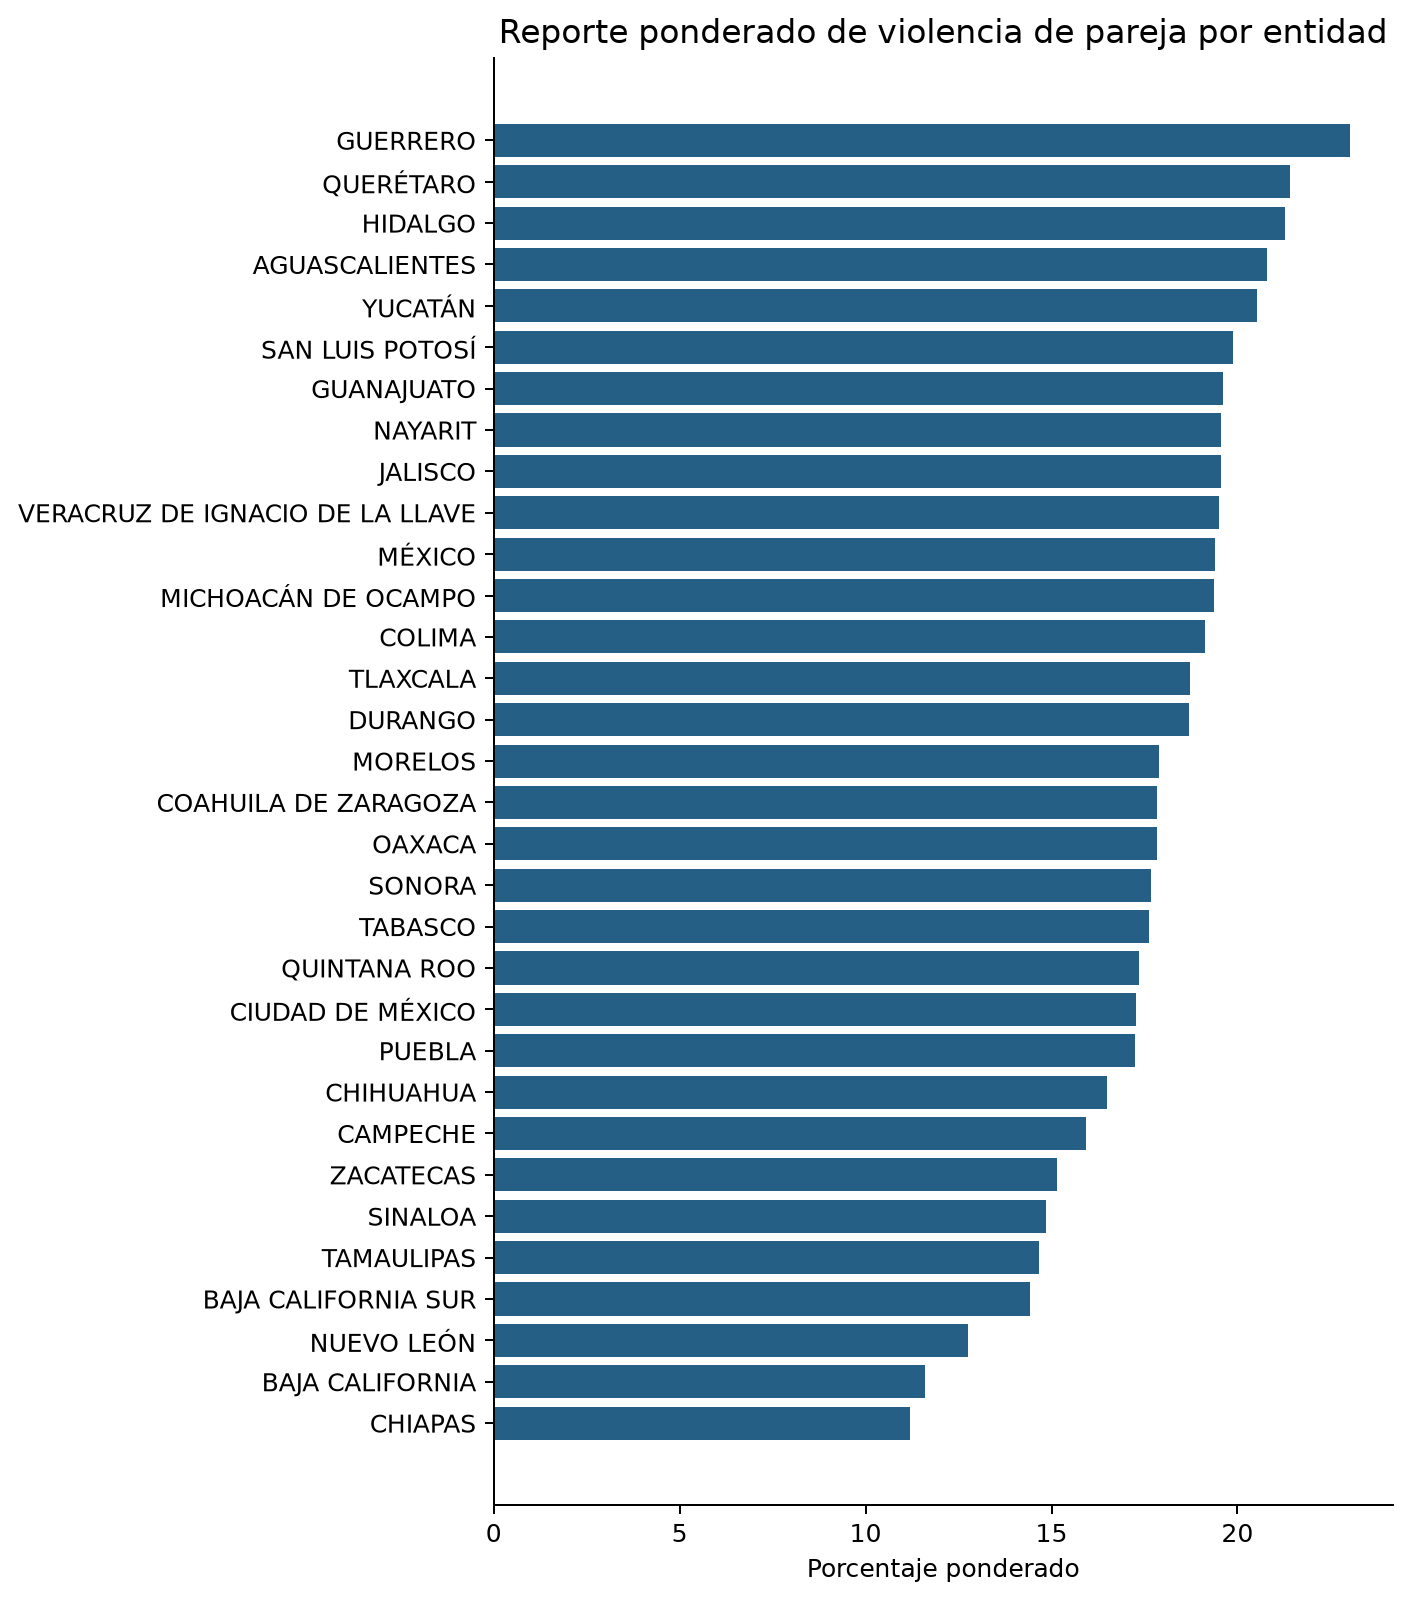

In [4]:
generar_figuras()
for nombre in [
    '01_faltantes.png', '02_distribucion_edad.png', '03_distribucion_hijos.png',
    '04_violencia_muestra_ponderada.png', '05_edad_por_violencia.png',
    '06_violencia_por_entidad.png'
]:
    display(Image(filename=RUTA_FIGURAS / nombre, width=850))

## Lectura responsable

Las diferencias entre grupos o entidades son descriptivas y pueden estar relacionadas con composición demográfica, cobertura, patrones de respuesta y diseño muestral. No deben interpretarse como características intrínsecas de las mujeres ni como pruebas de causalidad.